# Drone Recognition with Vision Transformer Fine-tuning

## Overview
This notebook fine-tunes a Vision Transformer (ViT) model for binary image classification (drone vs not-drone) using the [Hibou-Foundation/computer-vision](https://huggingface.co/datasets/Hibou-Foundation/computer-vision) dataset from Hugging Face.

## Dataset
- **Source**: Hibou-Foundation/computer-vision
- **Task**: Binary image classification
- **Classes**: drone (1) vs not-drone (0)
- **Size**: ~4,614 images


## 1. Setup and Dependencies


In [ ]:
# Install required packages if needed
# !pip install transformers datasets torch torchvision Pillow matplotlib seaborn scikit-learn accelerate -q


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import numpy as np
from datasets import load_dataset, DatasetDict
from transformers import (
    AutoImageProcessor,
    ViTForImageClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import os
from tqdm.auto import tqdm
import random
from typing import Dict, List, Tuple

# Set style for plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")


/home/pierre/Documents/Projects/PST4/AI/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version: {torch.version.cuda}")

# Set random seeds for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
print("Random seeds set for reproducibility")


Using device: cuda
GPU: NVIDIA GeForce RTX 4070 Laptop GPU
CUDA Version: 12.8
Random seeds set for reproducibility


## 2. Dataset Loading and Exploration


In [3]:
# Load dataset from Hugging Face
dataset_name = "Hibou-Foundation/computer-vision"
print(f"Loading dataset: {dataset_name}")

# Load the dataset
dataset = load_dataset(dataset_name)

# Check dataset structure
print("\nDataset structure:")
print(dataset)
print("\nDataset features:")
print(dataset['train_validation_test'].features)
print(f"\nTotal samples: {len(dataset['train_validation_test'])}")


Loading dataset: Hibou-Foundation/computer-vision


Generating train_validation_test split: 100%|██████████| 4614/4614 [00:03<00:00, 1289.00 examples/s]


Dataset structure:
DatasetDict({
    train_validation_test: Dataset({
        features: ['image', 'class_id', 'class_name', 'box', 'name', 'raw_label'],
        num_rows: 4614
    })
})

Dataset features:
{'image': Image(mode=None, decode=True), 'class_id': Value('int64'), 'class_name': Value('string'), 'box': List(Value('string')), 'name': Value('string'), 'raw_label': Value('string')}

Total samples: 4614


In [4]:
# Explore dataset structure
sample = dataset['train_validation_test'][0]
print("Sample data structure:")
for key, value in sample.items():
    if key == 'image':
        print(f"{key}: PIL Image, size: {value.size}, mode: {value.mode}")
    elif isinstance(value, list) and len(value) > 0:
        print(f"{key}: {type(value).__name__}, length: {len(value)}, first element: {value[0]}")
    else:
        print(f"{key}: {type(value).__name__}, value: {value}")


Sample data structure:
image: PIL Image, size: (1280, 720), mode: RGB
class_id: int, value: 0
class_name: str, value: drone
box: list, length: 4, first element: 0.539758
name: str, value: 0.jpg
raw_label: str, value: 0 0.539758 0.325448 0.063850 0.052038


Class distribution:
  Class 0 (drone): 4327 samples
  Class 1 (non-drone): 287 samples


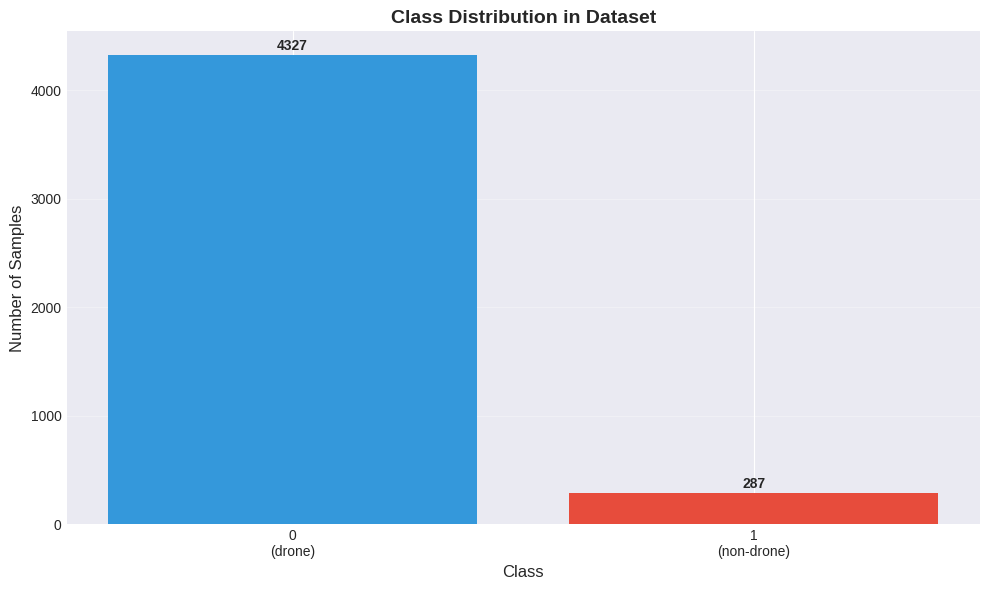

In [5]:
# Analyze class distribution
full_dataset = dataset['train_validation_test']

# Count classes
class_counts = {}
class_names = {}
for item in full_dataset:
    class_id = item['class_id']
    class_name = item['class_name']
    class_counts[class_id] = class_counts.get(class_id, 0) + 1
    if class_id not in class_names:
        class_names[class_id] = class_name

print("Class distribution:")
for class_id in sorted(class_counts.keys()):
    print(f"  Class {class_id} ({class_names[class_id]}): {class_counts[class_id]} samples")

# Visualize class distribution
plt.figure(figsize=(10, 6))
classes = sorted(class_counts.keys())
counts = [class_counts[c] for c in classes]
labels = [f"{c}\n({class_names[c]})" for c in classes]

plt.bar(labels, counts, color=['#3498db', '#e74c3c'])
plt.xlabel('Class', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
plt.title('Class Distribution in Dataset', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
for i, count in enumerate(counts):
    plt.text(i, count + 20, str(count), ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()


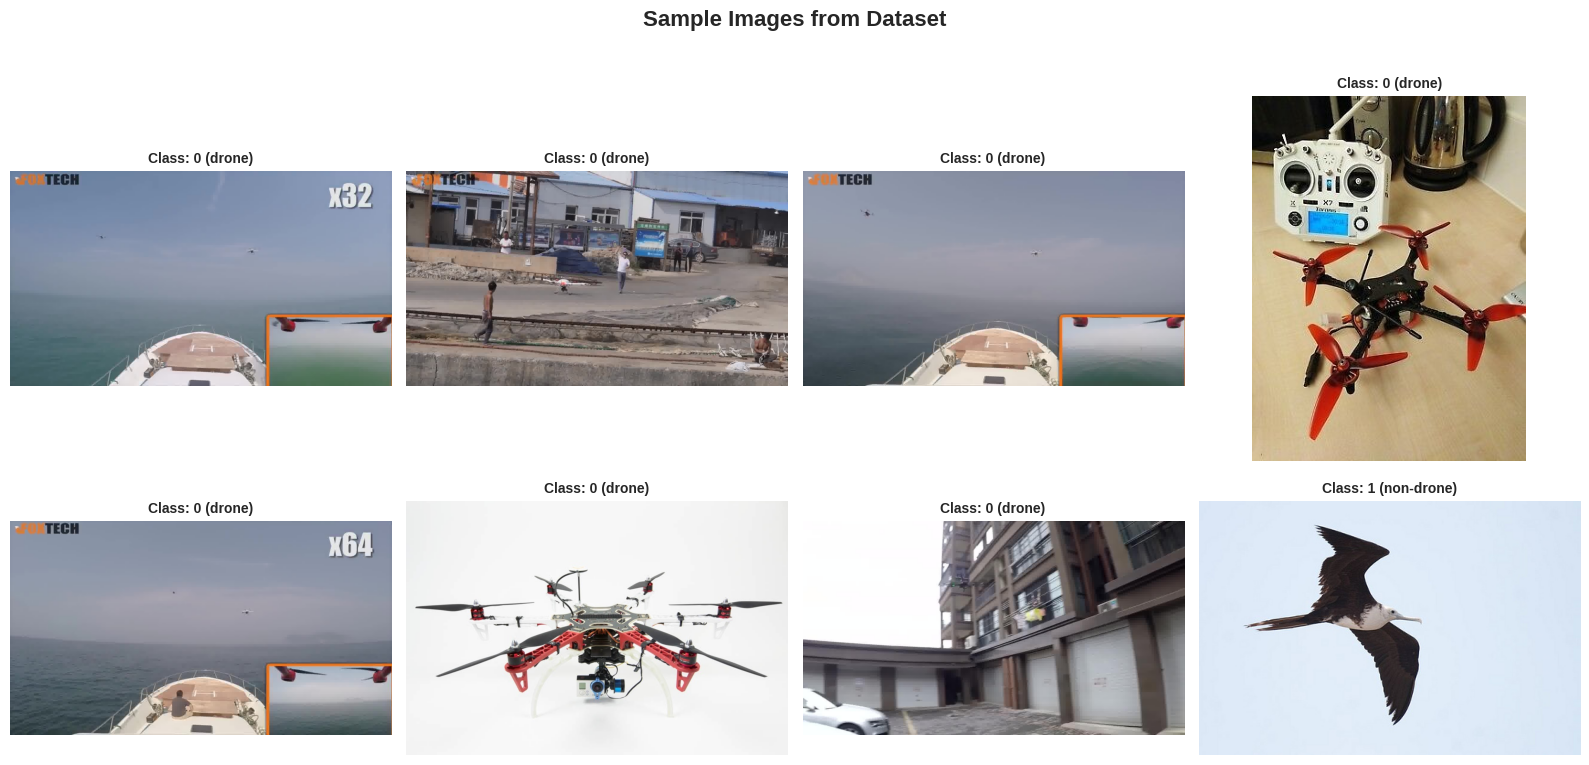

In [6]:
# Visualize sample images with their labels
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

# Sample random images
sample_indices = random.sample(range(len(full_dataset)), min(8, len(full_dataset)))

for idx, sample_idx in enumerate(sample_indices):
    item = full_dataset[sample_idx]
    image = item['image']
    class_id = item['class_id']
    class_name = item['class_name']
    
    axes[idx].imshow(image)
    axes[idx].set_title(f"Class: {class_id} ({class_name})", fontsize=10, fontweight='bold')
    axes[idx].axis('off')

plt.suptitle('Sample Images from Dataset', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 3. Data Preprocessing


In [7]:
# Model configuration
MODEL_NAME = "google/vit-base-patch16-224"
print(f"Loading image processor for: {MODEL_NAME}")

# Initialize image processor
image_processor = AutoImageProcessor.from_pretrained(MODEL_NAME)
print("Image processor loaded successfully")
print(f"Image size: {image_processor.size}")
print(f"Mean: {image_processor.image_mean}")
print(f"Std: {image_processor.image_std}")


Loading image processor for: google/vit-base-patch16-224


Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


Image processor loaded successfully
Image size: {'height': 224, 'width': 224}
Mean: [0.5, 0.5, 0.5]
Std: [0.5, 0.5, 0.5]


In [8]:
# Prepare dataset splits
# The dataset appears to have a single split, so we'll create train/val/test splits
full_data = dataset['train_validation_test']

# Shuffle and split: 70% train, 15% validation, 15% test
full_data = full_data.shuffle(seed=42)
total_size = len(full_data)
train_size = int(0.7 * total_size)
val_size = int(0.15 * total_size)

train_dataset = full_data.select(range(0, train_size))
val_dataset = full_data.select(range(train_size, train_size + val_size))
test_dataset = full_data.select(range(train_size + val_size, total_size))

print(f"Train size: {len(train_dataset)}")
print(f"Validation size: {len(val_dataset)}")
print(f"Test size: {len(test_dataset)}")
print(f"Total: {len(train_dataset) + len(val_dataset) + len(test_dataset)}")


Train size: 3229
Validation size: 692
Test size: 693
Total: 4614


In [9]:
# Define preprocessing function
def preprocess_images(examples):
    """Preprocess images for ViT model."""
    images = examples['image']
    
    # Process images
    inputs = image_processor(images, return_tensors="pt")
    
    # Convert class_id to label (assuming binary classification: drone=1, not-drone=0)
    # Based on the dataset, class_id 0 seems to be "drone"
    # We'll create binary labels: drone=1, other=0
    labels = []
    for class_id in examples['class_id']:
        # If class_id is 0 (drone), label is 1; otherwise 0
        # Adjust this logic based on your actual class mapping
        label = 1 if class_id == 0 else 0
        labels.append(label)
    
    inputs['labels'] = labels
    return inputs


In [10]:
# Apply preprocessing to all splits
print("Preprocessing training set...")
train_dataset_processed = train_dataset.map(
    preprocess_images,
    batched=True,
    batch_size=32,
    remove_columns=['image', 'class_id', 'class_name', 'box', 'name', 'raw_label']
)

print("Preprocessing validation set...")
val_dataset_processed = val_dataset.map(
    preprocess_images,
    batched=True,
    batch_size=32,
    remove_columns=['image', 'class_id', 'class_name', 'box', 'name', 'raw_label']
)

print("Preprocessing test set...")
test_dataset_processed = test_dataset.map(
    preprocess_images,
    batched=True,
    batch_size=32,
    remove_columns=['image', 'class_id', 'class_name', 'box', 'name', 'raw_label']
)

print("\nPreprocessing complete!")
print(f"Train features: {train_dataset_processed.features}")
print(f"Sample train item keys: {list(train_dataset_processed[0].keys())}")


Preprocessing training set...


Map: 100%|██████████| 3229/3229 [00:53<00:00, 60.61 examples/s]


Preprocessing validation set...


Map: 100%|██████████| 692/692 [00:11<00:00, 62.53 examples/s]


Preprocessing test set...


Map: 100%|██████████| 693/693 [00:10<00:00, 69.26 examples/s]



Preprocessing complete!
Train features: {'pixel_values': List(List(List(Value('float32')))), 'labels': Value('int64')}
Sample train item keys: ['pixel_values', 'labels']


In [11]:
# Set format for PyTorch
train_dataset_processed.set_format("torch")
val_dataset_processed.set_format("torch")
test_dataset_processed.set_format("torch")

# Verify label distribution in processed datasets
def check_labels(dataset, name):
    labels = [item['labels'].item() for item in dataset]
    unique, counts = np.unique(labels, return_counts=True)
    print(f"\n{name} label distribution:")
    for label, count in zip(unique, counts):
        print(f"  Label {label}: {count} samples ({count/len(labels)*100:.1f}%)")

check_labels(train_dataset_processed, "Training")
check_labels(val_dataset_processed, "Validation")
check_labels(test_dataset_processed, "Test")



Training label distribution:
  Label 0: 195 samples (6.0%)
  Label 1: 3034 samples (94.0%)

Validation label distribution:
  Label 0: 45 samples (6.5%)
  Label 1: 647 samples (93.5%)

Test label distribution:
  Label 0: 47 samples (6.8%)
  Label 1: 646 samples (93.2%)


## 4. Model Setup


In [12]:
# Load pre-trained ViT model for binary classification
print(f"Loading model: {MODEL_NAME}")

model = ViTForImageClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,  # Binary classification: drone vs not-drone
    ignore_mismatched_sizes=True  # In case of size mismatches
)

# Update label mappings
model.config.id2label = {0: "not-drone", 1: "drone"}
model.config.label2id = {"not-drone": 0, "drone": 1}

print("Model loaded successfully!")
print(f"Model type: {type(model)}")
print(f"Number of labels: {model.config.num_labels}")
print(f"Label mappings: {model.config.id2label}")


Loading model: google/vit-base-patch16-224


Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([2]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([2, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model loaded successfully!
Model type: <class 'transformers.models.vit.modeling_vit.ViTForImageClassification'>
Number of labels: 2
Label mappings: {0: 'not-drone', 1: 'drone'}


In [13]:
# Move model to device
model = model.to(device)
print(f"Model moved to {device}")

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Non-trainable parameters: {total_params - trainable_params:,}")


Model moved to cuda

Total parameters: 85,800,194
Trainable parameters: 85,800,194
Non-trainable parameters: 0


## 5. Training Configuration


In [14]:
# Define metrics computation function
def compute_metrics(eval_pred):
    """Compute accuracy, precision, recall, and F1-score."""
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    
    accuracy = accuracy_score(labels, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average='weighted', zero_division=0
    )
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }


In [15]:
# Training arguments
output_dir = "./drone_vit_checkpoints"
os.makedirs(output_dir, exist_ok=True)

training_args = TrainingArguments(
    output_dir=output_dir,
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_dir=f"{output_dir}/logs",
    logging_steps=50,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=3,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,
    push_to_hub=False,
    report_to=None,  # Set to "wandb" if you want to use Weights & Biases
    seed=42,
    fp16=torch.cuda.is_available(),  # Use mixed precision if GPU available
    dataloader_num_workers=4,
    remove_unused_columns=False,
)

print("Training arguments configured:")
for key, value in training_args.to_dict().items():
    print(f"  {key}: {value}")


Training arguments configured:
  output_dir: ./drone_vit_checkpoints
  overwrite_output_dir: False
  do_train: False
  do_eval: True
  do_predict: False
  eval_strategy: epoch
  prediction_loss_only: False
  per_device_train_batch_size: 16
  per_device_eval_batch_size: 16
  per_gpu_train_batch_size: None
  per_gpu_eval_batch_size: None
  gradient_accumulation_steps: 1
  eval_accumulation_steps: None
  eval_delay: 0
  torch_empty_cache_steps: None
  learning_rate: 2e-05
  weight_decay: 0.01
  adam_beta1: 0.9
  adam_beta2: 0.999
  adam_epsilon: 1e-08
  max_grad_norm: 1.0
  num_train_epochs: 5
  max_steps: -1
  lr_scheduler_type: linear
  lr_scheduler_kwargs: None
  warmup_ratio: 0.0
  warmup_steps: 0
  log_level: passive
  log_level_replica: warning
  log_on_each_node: True
  logging_dir: ./drone_vit_checkpoints/logs
  logging_strategy: steps
  logging_first_step: False
  logging_steps: 50
  logging_nan_inf_filter: True
  save_strategy: epoch
  save_steps: 500
  save_total_limit: 3
  sav

## 6. Training Loop


In [16]:
# Initialize Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset_processed,
    eval_dataset=val_dataset_processed,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

print("Trainer initialized successfully!")
print(f"Training samples: {len(train_dataset_processed)}")
print(f"Validation samples: {len(val_dataset_processed)}")


Trainer initialized successfully!
Training samples: 3229
Validation samples: 692


In [18]:
# Start training
print("Starting training...")
print("=" * 50)

train_results = trainer.train()

print("=" * 50)
print("Training completed!")
print(f"\nTraining loss: {train_results.training_loss:.4f}")
print(f"Training runtime: {train_results.metrics.get('train_runtime', 0):.2f} seconds")


Starting training...


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.001500,0.001060,1.000000,1.000000,1.000000,1.000000
2,0.000400,0.000581,1.000000,1.000000,1.000000,1.000000
3,0.000200,0.000449,1.000000,1.000000,1.000000,1.000000
4,0.000100,0.000384,1.000000,1.000000,1.000000,1.000000


Training completed!

Training loss: 0.0082
Training runtime: 96.43 seconds


In [19]:
# Save the final model
final_model_path = f"{output_dir}/final_model"
trainer.save_model(final_model_path)
image_processor.save_pretrained(final_model_path)
print(f"Model saved to: {final_model_path}")


Model saved to: ./drone_vit_checkpoints/final_model


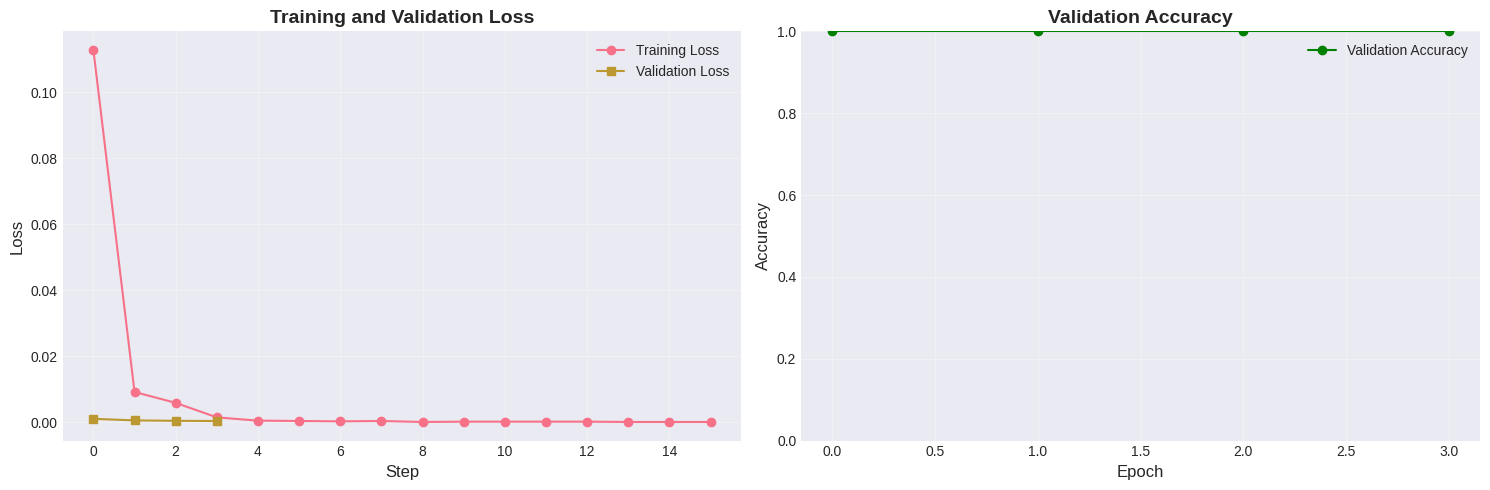

Final validation accuracy: 1.0000


In [20]:
# Plot training history
if hasattr(trainer.state, 'log_history'):
    history = trainer.state.log_history
    
    # Extract metrics
    train_losses = [x['loss'] for x in history if 'loss' in x]
    eval_losses = [x['eval_loss'] for x in history if 'eval_loss' in x]
    eval_accuracies = [x['eval_accuracy'] for x in history if 'eval_accuracy' in x]
    
    # Plot loss
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Loss plot
    axes[0].plot(train_losses, label='Training Loss', marker='o')
    if eval_losses:
        axes[0].plot(eval_losses, label='Validation Loss', marker='s')
    axes[0].set_xlabel('Step', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Accuracy plot
    if eval_accuracies:
        axes[1].plot(eval_accuracies, label='Validation Accuracy', marker='o', color='green')
        axes[1].set_xlabel('Epoch', fontsize=12)
        axes[1].set_ylabel('Accuracy', fontsize=12)
        axes[1].set_title('Validation Accuracy', fontsize=14, fontweight='bold')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        axes[1].set_ylim([0, 1])
    
    plt.tight_layout()
    plt.show()
    
    print(f"Final validation accuracy: {eval_accuracies[-1]:.4f}" if eval_accuracies else "No validation metrics available")


## 7. Evaluation


In [21]:
# Evaluate on test set
print("Evaluating on test set...")
test_results = trainer.evaluate(test_dataset_processed)

print("\nTest Set Results:")
print("=" * 50)
for key, value in test_results.items():
    if isinstance(value, float):
        print(f"{key}: {value:.4f}")
    else:
        print(f"{key}: {value}")
print("=" * 50)


Evaluating on test set...



Test Set Results:
eval_loss: 0.0011
eval_accuracy: 1.0000
eval_precision: 1.0000
eval_recall: 1.0000
eval_f1: 1.0000
eval_runtime: 1.5716
eval_samples_per_second: 440.9560
eval_steps_per_second: 27.9970
epoch: 4.0000


In [22]:
# Get predictions on test set
print("Generating predictions on test set...")
predictions = trainer.predict(test_dataset_processed)

# Extract predictions and labels
pred_labels = np.argmax(predictions.predictions, axis=1)
true_labels = predictions.label_ids

# Generate classification report
print("\nClassification Report:")
print("=" * 50)
print(classification_report(
    true_labels,
    pred_labels,
    target_names=['not-drone', 'drone'],
    digits=4
))
print("=" * 50)


Generating predictions on test set...

Classification Report:
              precision    recall  f1-score   support

   not-drone     1.0000    1.0000    1.0000        47
       drone     1.0000    1.0000    1.0000       646

    accuracy                         1.0000       693
   macro avg     1.0000    1.0000    1.0000       693
weighted avg     1.0000    1.0000    1.0000       693



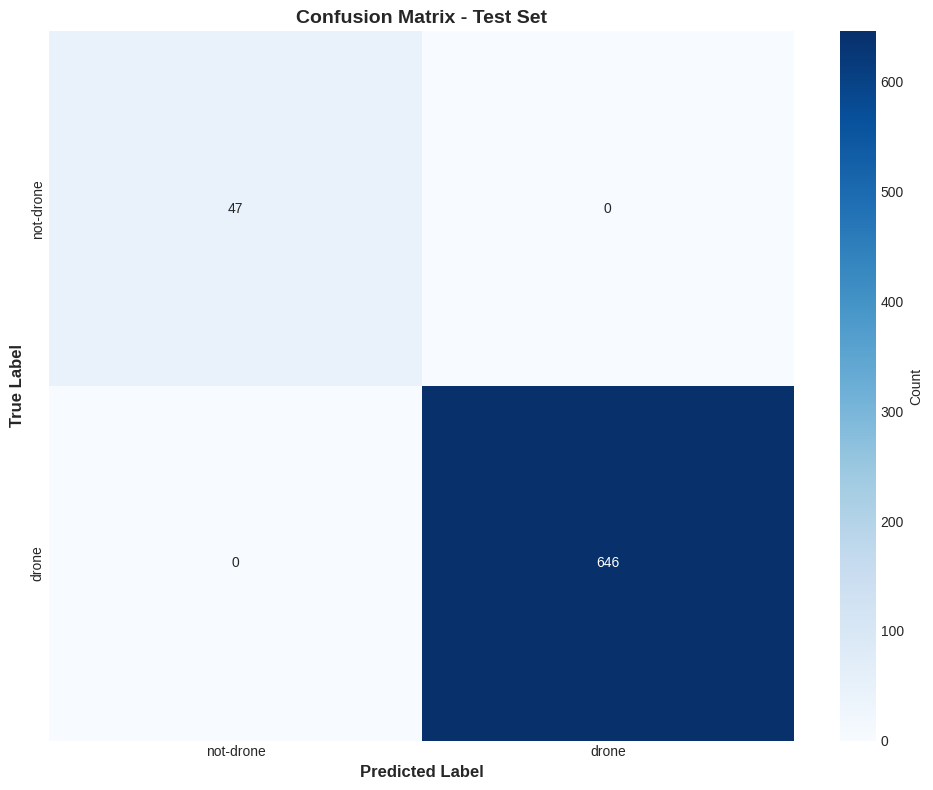


Per-class Accuracy:
  not-drone: 1.0000
  drone: 1.0000


In [23]:
# Create confusion matrix
cm = confusion_matrix(true_labels, pred_labels)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['not-drone', 'drone'],
    yticklabels=['not-drone', 'drone'],
    cbar_kws={'label': 'Count'}
)
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.title('Confusion Matrix - Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Calculate per-class accuracy
class_0_acc = cm[0, 0] / cm[0].sum() if cm[0].sum() > 0 else 0
class_1_acc = cm[1, 1] / cm[1].sum() if cm[1].sum() > 0 else 0

print(f"\nPer-class Accuracy:")
print(f"  not-drone: {class_0_acc:.4f}")
print(f"  drone: {class_1_acc:.4f}")


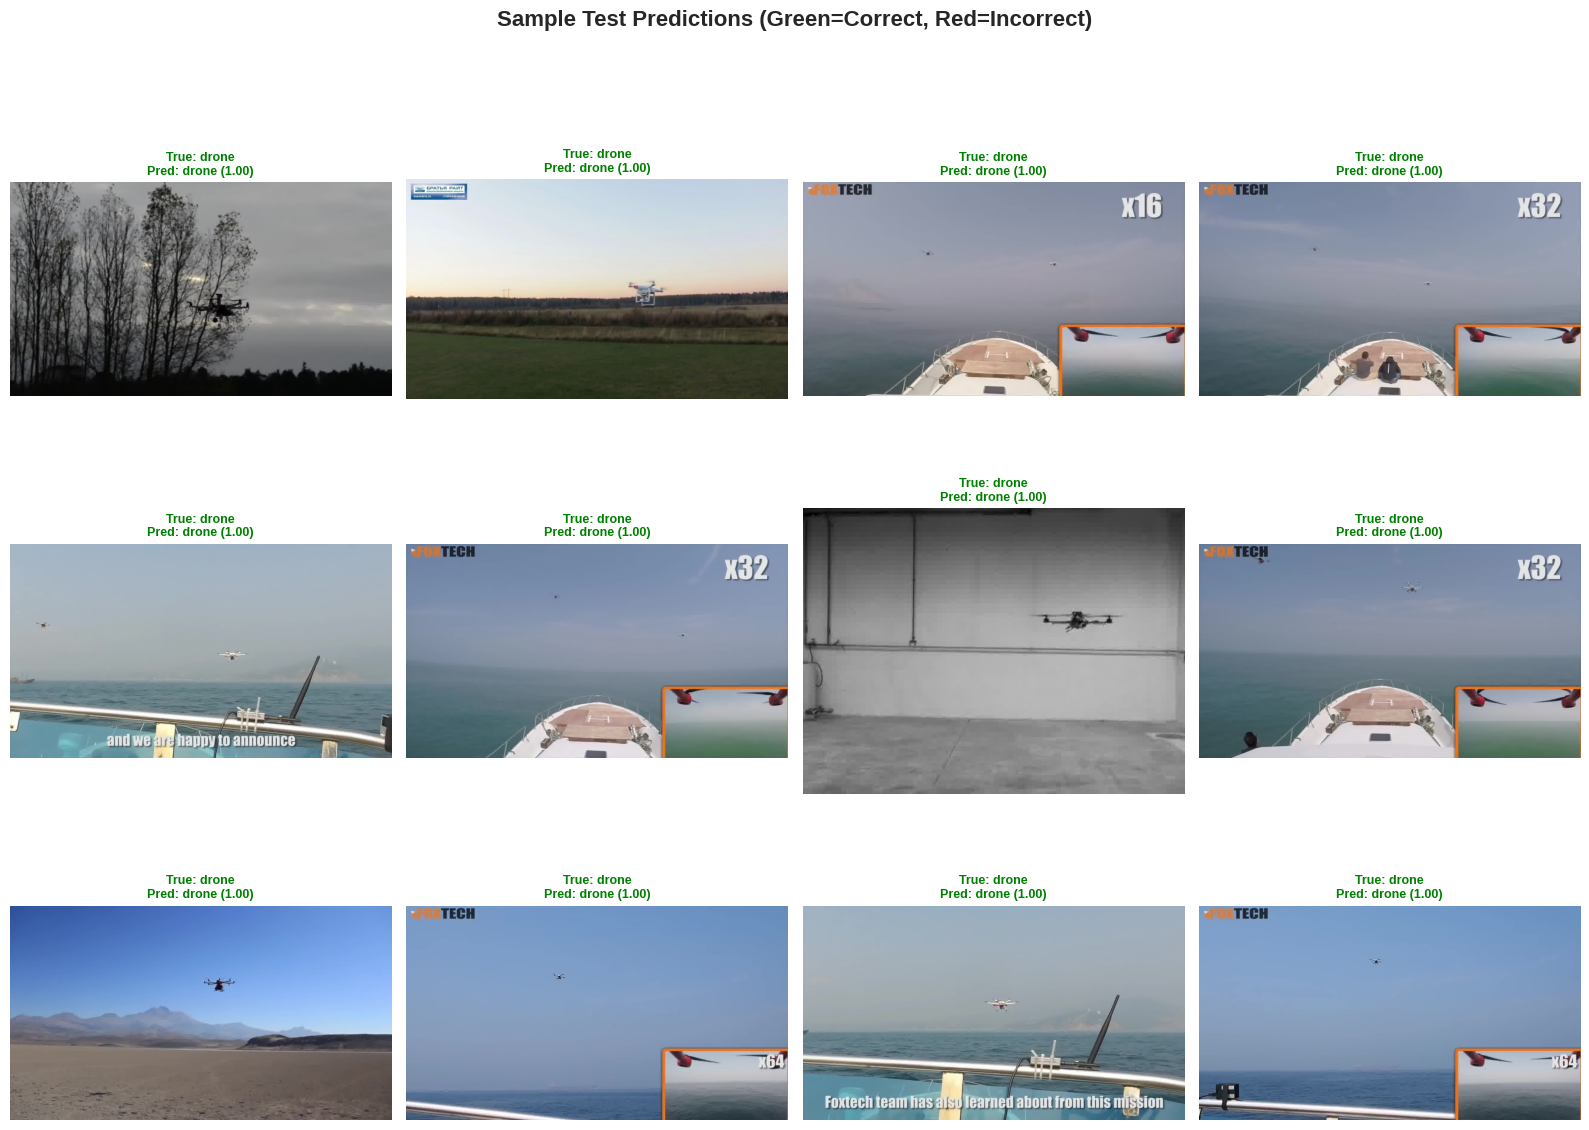


Correct predictions: 12/12
Incorrect predictions: 0/12


In [24]:
# Visualize predictions on sample test images
# First, we need to get the original images before preprocessing
test_indices = random.sample(range(len(test_dataset)), min(12, len(test_dataset)))

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

model.eval()
correct_predictions = []
incorrect_predictions = []

for idx, test_idx in enumerate(test_indices):
    # Get original image
    original_item = test_dataset[test_idx]
    original_image = original_item['image']
    true_label = original_item['class_id']
    true_label_binary = 1 if true_label == 0 else 0  # Convert to binary
    
    # Get processed data for prediction
    processed_item = test_dataset_processed[test_idx]
    
    # Prepare input
    pixel_values = processed_item['pixel_values'].unsqueeze(0).to(device)
    
    # Predict
    with torch.no_grad():
        outputs = model(pixel_values=pixel_values)
        logits = outputs.logits
        probs = torch.nn.functional.softmax(logits, dim=-1)
        pred_label = torch.argmax(logits, dim=-1).item()
        confidence = probs[0][pred_label].item()
    
    # Display image
    axes[idx].imshow(original_image)
    
    # Color: green for correct, red for incorrect
    color = 'green' if pred_label == true_label_binary else 'red'
    title = f"True: {'drone' if true_label_binary == 1 else 'not-drone'}\n"
    title += f"Pred: {'drone' if pred_label == 1 else 'not-drone'} ({confidence:.2f})"
    
    axes[idx].set_title(title, fontsize=9, fontweight='bold', color=color)
    axes[idx].axis('off')
    
    # Track predictions
    if pred_label == true_label_binary:
        correct_predictions.append((test_idx, true_label_binary, pred_label, confidence))
    else:
        incorrect_predictions.append((test_idx, true_label_binary, pred_label, confidence))

plt.suptitle('Sample Test Predictions (Green=Correct, Red=Incorrect)', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\nCorrect predictions: {len(correct_predictions)}/{len(test_indices)}")
print(f"Incorrect predictions: {len(incorrect_predictions)}/{len(test_indices)}")


## 8. Inference and Visualization


In [25]:
# Inference function for single image
def predict_image(image_path_or_pil, model, processor, device):
    """
    Predict class for a single image.
    
    Args:
        image_path_or_pil: Path to image file or PIL Image object
        model: Trained model
        processor: Image processor
        device: Device to run inference on
    
    Returns:
        dict: Prediction results with class, confidence, and probabilities
    """
    # Load image if path provided
    if isinstance(image_path_or_pil, str):
        image = Image.open(image_path_or_pil).convert('RGB')
    else:
        image = image_path_or_pil
    
    # Preprocess image
    inputs = processor(image, return_tensors="pt").to(device)
    
    # Predict
    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        probs = torch.nn.functional.softmax(logits, dim=-1)
        pred_label = torch.argmax(logits, dim=-1).item()
        confidence = probs[0][pred_label].item()
    
    # Get class name
    class_name = model.config.id2label[pred_label]
    
    return {
        'class_id': pred_label,
        'class_name': class_name,
        'confidence': confidence,
        'probabilities': {
            model.config.id2label[i]: probs[0][i].item() 
            for i in range(len(model.config.id2label))
        }
    }

print("Inference function defined!")


Inference function defined!


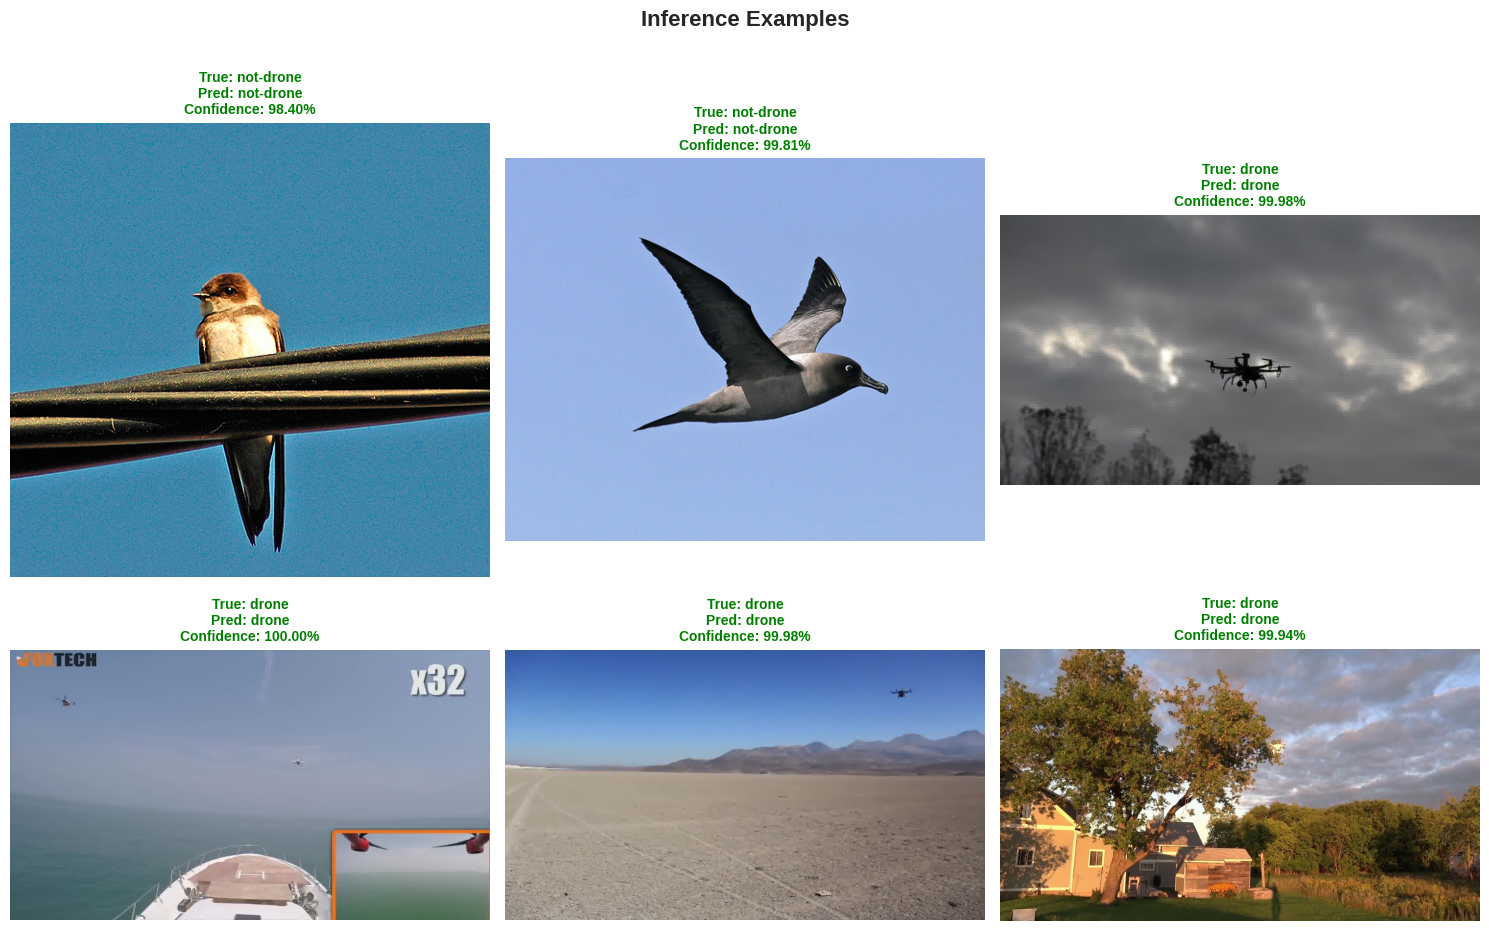

In [26]:
# Test inference on a few sample images
sample_images = random.sample(range(len(test_dataset)), min(6, len(test_dataset)))

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, sample_idx in enumerate(sample_images):
    original_item = test_dataset[sample_idx]
    original_image = original_item['image']
    true_label = original_item['class_id']
    true_label_binary = 1 if true_label == 0 else 0
    
    # Predict
    result = predict_image(original_image, model, image_processor, device)
    
    # Display
    axes[idx].imshow(original_image)
    
    title = f"True: {'drone' if true_label_binary == 1 else 'not-drone'}\n"
    title += f"Pred: {result['class_name']}\n"
    title += f"Confidence: {result['confidence']:.2%}"
    
    color = 'green' if result['class_id'] == true_label_binary else 'red'
    axes[idx].set_title(title, fontsize=10, fontweight='bold', color=color)
    axes[idx].axis('off')

plt.suptitle('Inference Examples', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


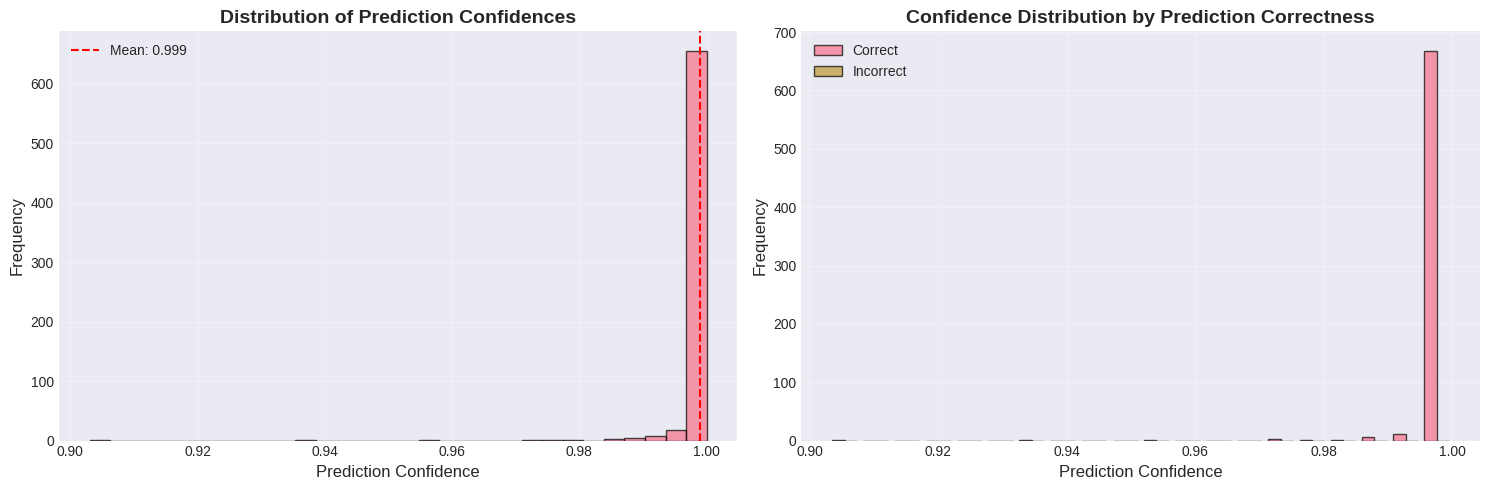


Confidence Statistics:
  Mean confidence: 0.9989
  Std confidence: 0.0052
  Mean confidence (correct): 0.9989
  Mean confidence (incorrect): nan


/home/pierre/Documents/Projects/PST4/AI/.venv/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/pierre/Documents/Projects/PST4/AI/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [27]:
# Analyze prediction confidence distribution
all_confidences = []
all_pred_labels = []
all_true_labels = []

for i in range(len(test_dataset)):
    original_item = test_dataset[i]
    processed_item = test_dataset_processed[i]
    
    true_label = original_item['class_id']
    true_label_binary = 1 if true_label == 0 else 0
    
    pixel_values = processed_item['pixel_values'].unsqueeze(0).to(device)
    
    with torch.no_grad():
        outputs = model(pixel_values=pixel_values)
        logits = outputs.logits
        probs = torch.nn.functional.softmax(logits, dim=-1)
        pred_label = torch.argmax(logits, dim=-1).item()
        confidence = probs[0][pred_label].item()
    
    all_confidences.append(confidence)
    all_pred_labels.append(pred_label)
    all_true_labels.append(true_label_binary)

# Plot confidence distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Confidence histogram
axes[0].hist(all_confidences, bins=30, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Prediction Confidence', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Distribution of Prediction Confidences', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].axvline(np.mean(all_confidences), color='red', linestyle='--', 
                label=f'Mean: {np.mean(all_confidences):.3f}')
axes[0].legend()

# Confidence by correctness
correct_confidences = [conf for conf, pred, true in zip(all_confidences, all_pred_labels, all_true_labels) 
                       if pred == true]
incorrect_confidences = [conf for conf, pred, true in zip(all_confidences, all_pred_labels, all_true_labels) 
                         if pred != true]

axes[1].hist([correct_confidences, incorrect_confidences], bins=20, 
             label=['Correct', 'Incorrect'], alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Prediction Confidence', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Confidence Distribution by Prediction Correctness', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nConfidence Statistics:")
print(f"  Mean confidence: {np.mean(all_confidences):.4f}")
print(f"  Std confidence: {np.std(all_confidences):.4f}")
print(f"  Mean confidence (correct): {np.mean(correct_confidences):.4f}")
print(f"  Mean confidence (incorrect): {np.mean(incorrect_confidences):.4f}")


### Important: Classification vs Object Detection

**What this model does:**
- ✅ **Classification**: Predicts whether a drone is present in the image (drone vs not-drone)
- ❌ **Object Detection**: Does NOT locate where the drone is in the image (no bounding boxes)

The dataset contains bounding box annotations, but this model only uses them for classification labels. To actually **find/locate** drones in images, you would need an **object detection model** (like DETR, YOLO, or a ViT-based object detector).


In [ ]:
# Visualize bounding boxes from the dataset to show what detection would look like
# Note: The model doesn't predict these boxes, but the dataset has them

def draw_bbox_on_image(image, bbox_list, color='red', linewidth=2):
    """Draw bounding boxes on an image."""
    from PIL import ImageDraw
    
    img_copy = image.copy()
    draw = ImageDraw.Draw(img_copy)
    
    # bbox_list contains normalized coordinates [x_center, y_center, width, height]
    # Convert to pixel coordinates
    img_width, img_height = image.size
    
    for i in range(0, len(bbox_list), 4):
        if i + 3 < len(bbox_list):
            x_center = float(bbox_list[i]) * img_width
            y_center = float(bbox_list[i+1]) * img_width
            width = float(bbox_list[i+2]) * img_width
            height = float(bbox_list[i+3]) * img_height
            
            # Convert center coordinates to top-left corner
            x1 = x_center - width / 2
            y1 = y_center - height / 2
            x2 = x_center + width / 2
            y2 = y_center + height / 2
            
            # Draw rectangle
            draw.rectangle([x1, y1, x2, y2], outline=color, width=linewidth)
    
    return img_copy

# Show sample images with bounding boxes from the dataset
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

# Get samples with bounding boxes
samples_with_boxes = []
for i in range(len(full_dataset)):
    item = full_dataset[i]
    if item['box'] and len(item['box']) >= 4:
        samples_with_boxes.append(i)
    if len(samples_with_boxes) >= 6:
        break

if len(samples_with_boxes) > 0:
    for idx, sample_idx in enumerate(samples_with_boxes[:6]):
        item = full_dataset[sample_idx]
        image = item['image']
        bbox = item['box']
        class_name = item['class_name']
        
        # Draw bounding boxes
        image_with_bbox = draw_bbox_on_image(image, bbox, color='red', linewidth=3)
        
        axes[idx].imshow(image_with_bbox)
        axes[idx].set_title(f"Dataset bbox: {class_name}\n(Our model doesn't predict these)", 
                           fontsize=10, fontweight='bold')
        axes[idx].axis('off')
    
    plt.suptitle('Bounding Boxes in Dataset (What Object Detection Would Predict)', 
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    
    print("\n" + "="*60)
    print("EXPLANATION:")
    print("="*60)
    print("The red boxes above show WHERE the drones are located in the images.")
    print("These bounding boxes come from the dataset annotations.")
    print("\nOur current model:")
    print("  ✅ Can tell you: 'Yes, there is a drone in this image'")
    print("  ❌ Cannot tell you: 'The drone is at coordinates (x, y, w, h)'")
    print("\nTo locate drones, you would need an OBJECT DETECTION model,")
    print("not a CLASSIFICATION model like this one.")
    print("="*60)
else:
    print("No bounding boxes found in sample images.")


## 9. Model Iteration


In [ ]:
# Hyperparameter tuning section
# You can experiment with different hyperparameters here

# Example: Try different learning rates
learning_rates = [1e-5, 2e-5, 5e-5]
batch_sizes = [8, 16, 32]

print("Hyperparameter Options:")
print(f"Learning rates to try: {learning_rates}")
print(f"Batch sizes to try: {batch_sizes}")
print("\nTo iterate with different hyperparameters:")
print("1. Modify training_args with new values")
print("2. Reinitialize trainer")
print("3. Train and compare results")
print("4. Save best model configuration")


In [ ]:
# Function to train with different hyperparameters
def train_with_hyperparameters(lr, batch_size, epochs=3, model_name_suffix=""):
    """
    Train model with specified hyperparameters.
    
    Returns:
        dict: Training results and metrics
    """
    # Create new output directory
    output_dir_iter = f"./drone_vit_checkpoints_iter_{model_name_suffix}"
    os.makedirs(output_dir_iter, exist_ok=True)
    
    # Training arguments
    training_args_iter = TrainingArguments(
        output_dir=output_dir_iter,
        num_train_epochs=epochs,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        learning_rate=lr,
        weight_decay=0.01,
        logging_dir=f"{output_dir_iter}/logs",
        logging_steps=50,
        eval_strategy="epoch",
        save_strategy="epoch",
        save_total_limit=2,
        load_best_model_at_end=True,
        metric_for_best_model="accuracy",
        greater_is_better=True,
        push_to_hub=False,
        report_to=None,
        seed=42,
        fp16=torch.cuda.is_available(),
        dataloader_num_workers=4,
        remove_unused_columns=False,
    )
    
    # Load fresh model
    model_iter = ViTForImageClassification.from_pretrained(
        MODEL_NAME,
        num_labels=2,
        ignore_mismatched_sizes=True
    )
    model_iter.config.id2label = {0: "not-drone", 1: "drone"}
    model_iter.config.label2id = {"not-drone": 0, "drone": 1}
    model_iter = model_iter.to(device)
    
    # Initialize trainer
    trainer_iter = Trainer(
        model=model_iter,
        args=training_args_iter,
        train_dataset=train_dataset_processed,
        eval_dataset=val_dataset_processed,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
    )
    
    # Train
    train_results_iter = trainer_iter.train()
    
    # Evaluate
    eval_results_iter = trainer_iter.evaluate(val_dataset_processed)
    test_results_iter = trainer_iter.evaluate(test_dataset_processed)
    
    return {
        'lr': lr,
        'batch_size': batch_size,
        'epochs': epochs,
        'train_loss': train_results_iter.training_loss,
        'val_accuracy': eval_results_iter.get('eval_accuracy', 0),
        'test_accuracy': test_results_iter.get('eval_accuracy', 0),
        'output_dir': output_dir_iter
    }

print("Hyperparameter training function defined!")
print("Use this function to experiment with different configurations.")


In [ ]:
# Example: Compare different learning rates (commented out to avoid long training)
# Uncomment and run to experiment with hyperparameters

"""
results_comparison = []

# Try different learning rates
for lr in [1e-5, 2e-5, 5e-5]:
    print(f"\n{'='*50}")
    print(f"Training with learning rate: {lr}")
    print(f"{'='*50}")
    result = train_with_hyperparameters(lr=lr, batch_size=16, epochs=3, model_name_suffix=f"lr_{lr}")
    results_comparison.append(result)

# Compare results
comparison_df = pd.DataFrame(results_comparison)
print("\nHyperparameter Comparison:")
print(comparison_df.to_string(index=False))

# Find best configuration
best_idx = comparison_df['val_accuracy'].idxmax()
best_config = comparison_df.loc[best_idx]
print(f"\nBest configuration:")
print(f"  Learning rate: {best_config['lr']}")
print(f"  Batch size: {best_config['batch_size']}")
print(f"  Validation accuracy: {best_config['val_accuracy']:.4f}")
print(f"  Test accuracy: {best_config['test_accuracy']:.4f}")
"""


In [ ]:
# Load saved model checkpoint
def load_model_checkpoint(checkpoint_path):
    """Load a saved model checkpoint."""
    model_loaded = ViTForImageClassification.from_pretrained(checkpoint_path)
    processor_loaded = AutoImageProcessor.from_pretrained(checkpoint_path)
    model_loaded = model_loaded.to(device)
    return model_loaded, processor_loaded

# Example usage:
# best_model, best_processor = load_model_checkpoint("./drone_vit_checkpoints/checkpoint-XXX")
# print("Model loaded from checkpoint!")

print("Model loading function defined!")
print("Use load_model_checkpoint() to load saved checkpoints for continued training or inference.")


## 10. Results Summary


In [ ]:
# Final model performance summary
print("=" * 60)
print("FINAL MODEL PERFORMANCE SUMMARY")
print("=" * 60)

# Test set metrics
test_accuracy = accuracy_score(true_labels, pred_labels)
precision, recall, f1, _ = precision_recall_fscore_support(
    true_labels, pred_labels, average='weighted', zero_division=0
)

print(f"\nTest Set Metrics:")
print(f"  Accuracy:  {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1-Score:  {f1:.4f}")

# Per-class metrics
precision_per_class, recall_per_class, f1_per_class, _ = precision_recall_fscore_support(
    true_labels, pred_labels, average=None, zero_division=0
)

print(f"\nPer-Class Metrics:")
print(f"  {'Class':<15} {'Precision':<12} {'Recall':<12} {'F1-Score':<12}")
print(f"  {'-'*50}")
for i, class_name in enumerate(['not-drone', 'drone']):
    print(f"  {class_name:<15} {precision_per_class[i]:<12.4f} {recall_per_class[i]:<12.4f} {f1_per_class[i]:<12.4f}")

# Model info
print(f"\nModel Information:")
print(f"  Model: {MODEL_NAME}")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")
print(f"  Model saved to: {final_model_path}")

print("\n" + "=" * 60)


In [ ]:
# Save results to file
results_summary = {
    'model': MODEL_NAME,
    'test_accuracy': float(test_accuracy),
    'test_precision': float(precision),
    'test_recall': float(recall),
    'test_f1': float(f1),
    'per_class_precision': {
        'not-drone': float(precision_per_class[0]),
        'drone': float(precision_per_class[1])
    },
    'per_class_recall': {
        'not-drone': float(recall_per_class[0]),
        'drone': float(recall_per_class[1])
    },
    'per_class_f1': {
        'not-drone': float(f1_per_class[0]),
        'drone': float(f1_per_class[1])
    },
    'total_params': int(total_params),
    'trainable_params': int(trainable_params),
    'model_path': final_model_path
}

import json
results_file = f"{output_dir}/results_summary.json"
with open(results_file, 'w') as f:
    json.dump(results_summary, f, indent=2)

print(f"Results summary saved to: {results_file}")
